## Classfication model evaluation Metrics
1. accuracy
2. area under ROC curve
3. confusion metrix
4. classfication report

In [3]:
import pandas as pd
import numpy as np

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

heart_disease = pd.read_csv("heart-disease.csv")

X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

model = RandomForestClassifier()
cross_val_score=cross_val_score(model, X, y, cv=5)
cross_val_score

array([0.85245902, 0.90163934, 0.73770492, 0.8       , 0.76666667])

In [5]:
np.mean(cross_val_score)*100

np.float64(82.47540983606557)

### Area Under Receiver Operating Characteristic (ROC) Curve

ROC specifies model's true positive rate VS model's false positive rate

* True Positive = predict TRUE, when real value is TRUE
* False Positive = predict TRUE, when real value is FALSE
* True Negative = predict FLASE, when real value is FALSE
* False Negative = predict FALSE, when real value is TRUE

In [7]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)
y_probs = model.predict_proba(X_test)
y_probs[:10]

array([[0.2 , 0.8 ],
       [0.63, 0.37],
       [0.21, 0.79],
       [0.7 , 0.3 ],
       [0.73, 0.27],
       [0.69, 0.31],
       [0.28, 0.72],
       [0.91, 0.09],
       [0.79, 0.21],
       [0.92, 0.08]])

In [8]:
y_probs_positives = y_probs[:,1]
y_probs_positives[:10]

array([0.8 , 0.37, 0.79, 0.3 , 0.27, 0.31, 0.72, 0.09, 0.21, 0.08])

In [11]:

fpr, tpr, thresholds = roc_curve(y_test, y_probs_positives)

fpr, tpr

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.03225806, 0.03225806, 0.06451613,
        0.06451613, 0.06451613, 0.06451613, 0.06451613, 0.12903226,
        0.12903226, 0.16129032, 0.16129032, 0.22580645, 0.22580645,
        0.25806452, 0.32258065, 0.38709677, 0.38709677, 0.41935484,
        0.48387097, 0.51612903, 0.5483871 , 0.61290323, 0.61290323,
        0.80645161, 0.90322581, 1.        ]),
 array([0.        , 0.03333333, 0.1       , 0.16666667, 0.2       ,
        0.26666667, 0.33333333, 0.33333333, 0.36666667, 0.4       ,
        0.46666667, 0.5       , 0.56666667, 0.66666667, 0.7       ,
        0.73333333, 0.73333333, 0.83333333, 0.83333333, 0.86666667,
        0.86666667, 0.9       , 0.9       , 0.93333333, 0.93333333,
        0.93333333, 0.93333333, 0.96666667, 0.96666667, 1.        ,
        1.        , 1.        , 1.        ]))

In [12]:
thresholds

array([ inf, 1.  , 0.96, 0.95, 0.9 , 0.89, 0.85, 0.84, 0.83, 0.8 , 0.79,
       0.76, 0.73, 0.72, 0.68, 0.63, 0.62, 0.51, 0.46, 0.43, 0.42, 0.41,
       0.32, 0.31, 0.3 , 0.29, 0.28, 0.27, 0.25, 0.23, 0.09, 0.08, 0.  ])

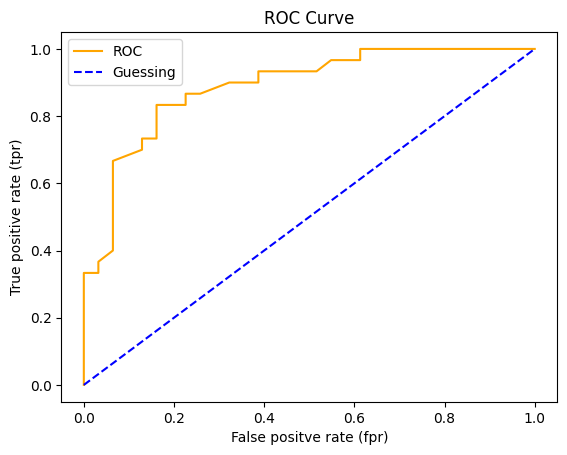

In [14]:
import matplotlib.pyplot as plt

def plot_roc_curve (fpr, tpr):
    plt.plot(fpr, tpr, color="orange", label="ROC")
    plt.plot([0, 1], [0, 1], color="blue", linestyle="--", label="Guessing")

    plt.xlabel("False positve rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr, tpr)

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs_positives)

0.871978021978022

In [ ]:
thresholds

array([ inf, 0.99, 0.97, 0.86, 0.84, 0.83, 0.82, 0.76, 0.74, 0.7 , 0.69,
       0.68, 0.67, 0.65, 0.64, 0.62, 0.59, 0.58, 0.54, 0.53, 0.46, 0.45,
       0.41, 0.38, 0.36, 0.35, 0.28, 0.24, 0.11, 0.08, 0.02])

* Curve closer to the top-left corner: Excellent model. High TPR, low FPR.
* Curve along diagonal: Model is no better than random guessing.
* Curve below diagonal: Model is worse than random (can flip predictions to improve).

### Confusion Metrics


In [16]:
from sklearn.metrics import confusion_matrix

y_preds = model.predict(X_test)
confusion_matrix(y_test, y_preds) # uses same threshold.

array([[26,  5],
       [ 5, 25]])

In [ ]:
pd.crosstab(y_test,
           y_preds,
           rownames=["Actual Label"],
            colnames=["predicted labels"])

predicted labels,0,1
Actual Label,,
0,19,7
1,4,31


### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print (classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78        26
           1       0.82      0.89      0.85        35

    accuracy                           0.82        61
   macro avg       0.82      0.81      0.81        61
weighted avg       0.82      0.82      0.82        61



* Accuracy: Percentage of all predictions that are correct.


  Example: (TP + TN) / (TP + TN + FP + FN) = (8 + 7) / (8+7+3+2) = 15/20 = 0.75 → 75%
  
* Precision: Of all predicted positives, how many are actually positive.


   Example: TP / (TP + FP) = 8 / (8 + 3) = 8/11 ≈ 0.727 → 72.7%

* Recall (Sensitivity): Of all actual positives, how many the model correctly found.


   Example: TP / (TP + FN) = 8 / (8 + 2) = 8/10 = 0.8 → 80%

* F1-Score: Balanced average of precision and recall, useful when classes are imbalanced. Is the model both correct (precision) and complete (recall)


   Example: 2 * (Precision * Recall) / (Precision + Recall) = 2*(0.727*0.8)/(0.727+0.8) ≈ 0.762 → 76.2%

### Regression Model Evaluation Metrics
1. R^2, coefficient of determination
2. Mean absolute error MAE
3. Mean squared error MSE

In [ ]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

california_df = pd.DataFrame(california["data"], columns=california["feature_names"])
california_df["target"] = pd.Series(california["target"])

california_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = california_df.drop("target", axis=1)
y = california_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8077911332854602

    Actual:     [100, 150, 200, 250, 300]
    Predicted:  [110, 140, 210, 240, 290]

**Step 1: Compute the total variation in actual data (differences from mean):**

    Mean = (100+150+200+250+300)/5 = 200
    Total variation = (100-200)² + (150-200)² + … + (300-200)² = 25000

**Step 2: Compute unexplained variation (differences from predictions):**
    (100-110)² + (150-140)² + … + (300-290)² = 1000

**Step 3: Compute R²**

R² formula:

$$
R^2 = 1 - \frac{\text{Unexplained variation}}{\text{Total variation}}
$$

- Total variation = $(100-200)^2 + (150-200)^2 + (200-200)^2 + (250-200)^2 + (300-200)^2 = 25000$  
- Unexplained variation = $(100-110)^2 + (150-140)^2 + (200-210)^2 + (250-240)^2 + (300-290)^2 = 1000$  

$$
R^2 = 1 - \frac{1000}{25000} = 0.96
$$

**Interpretation:** 96% of the variation in house prices is explained by the model.

### Mean Absolute Error (MAE)

The formula:

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

Where:  
- $y_i$ = actual value  
- $\hat{y}_i$ = predicted value  
- $n$ = number of samples  

**In simple words:** MAE is the average of the absolute differences between predicted and actual values.
Shows how wrong the predictions are on average.


In [ ]:
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(X_test)
mae = mean_absolute_error(y_test, y_preds)

mae

0.3326720609496126

### Mean Squared Error (MSE)

The formula:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Where:  
- $y_i$ = actual value  
- $\hat{y}_i$ = predicted value  
- $n$ = number of samples  

**In simple words:** MSE is the average of the **squared differences** between predicted and actual values, penalizing larger errors more heavily.


In [ ]:
from sklearn.metrics import mean_squared_error

y_preds = model.predict(X_test)
mse = mean_squared_error(y_test, y_preds)

mse

0.2538762935702716